# CNET 5442 – Sports Analytics through Data and Networks
## Assignment 3: How Often Do Bad Teams Beat Good Teams in the Premier League?

Liam Miller


---
## Setup & Imports

In [51]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)


DATA_DIR = 'data/'          
SEASONS  = list(range(2014, 2024))

print('Libraries loaded.')

Libraries loaded.


---
## Part (a) – Shot Data → Match Results

**How goals are computed from the shot data:**  
Each row in the CSV represents one shot attempt. The file already carries `home_goals` and `away_goals` columns that hold the final match score. They are constant across every shot row belonging to the same match. Therfore, the strategy is to deduplicate on `match_id` to obtain exactly one row per match. Then confirm that `home_goals` and `away_goals` take exactly one unique value per `match_id`.



In [5]:
def load_season(season: int, data_dir: str = DATA_DIR) -> pd.DataFrame:
    """Load one season's shot-level CSV."""
    path = os.path.join(data_dir, f'EPL_{season}_shots.csv')
    df = pd.read_csv(path, parse_dates=['date'])
    return df


def shots_to_matches(shots: pd.DataFrame) -> pd.DataFrame:
    """
    Convert shot-level rows into one row per match.

    Raw CSV columns used:
        season, match_id, date, home_team, away_team, home_goals, away_goals

    home_goals / away_goals are the final match scoreline, constant for
    every shot in the same match. We simply drop duplicates on match_id.
    """
    keep = ['season', 'match_id', 'date', 'home_team', 'away_team',
            'home_goals', 'away_goals']
    match_df = shots[keep].drop_duplicates(subset='match_id').copy()
    match_df['date'] = pd.to_datetime(match_df['date'])

    # Match result: H = home win, D = draw, A = away win
    def get_result(row):
        if row.home_goals > row.away_goals:
            return 'H'
        elif row.home_goals == row.away_goals:
            return 'D'
        else:
            return 'A'

    match_df['result'] = match_df.apply(get_result, axis=1)
    return match_df.sort_values(['season', 'date']).reset_index(drop=True)

In [6]:
# Load all seasons and build the combined match DataFrame
all_shots = pd.concat([load_season(s) for s in SEASONS], ignore_index=True)
match_df  = shots_to_matches(all_shots)

print(f'Total matches loaded: {len(match_df):,}')
match_df.head()

Total matches loaded: 3,800


,season,match_id,date,home_team,away_team,home_goals,away_goals,result
0,2014,4749,2014-08-16 12:45:00,Manchester United,Swansea,1,2,A
1,2014,4750,2014-08-16 15:00:00,Leicester,Everton,2,2,D
2,2014,4751,2014-08-16 15:00:00,Queens Park Rangers,Hull,0,1,A
3,2014,4752,2014-08-16 15:00:00,Stoke,Aston Villa,0,1,A
4,2014,4753,2014-08-16 15:00:00,West Bromwich Albion,Sunderland,2,2,D


### Sanity Check 1 – Home-win percentage per season

In [8]:
home_win_pct = (
    match_df
    .groupby('season')
    .apply(lambda g: (g['result'] == 'H').mean() * 100)
    .reset_index(name='home_win_pct_%')
)
print('Home-win percentage per season:')
print(home_win_pct.to_string(index=False))

Home-win percentage per season:
 season  home_win_pct_%
   2014       45.263158
   2015       41.315789
   2016       49.210526
   2017       45.526316
   2018       47.631579
   2019       45.263158
   2020       37.894737
   2021       42.894737
   2022       48.421053
   2023       46.052632


### Sanity Check 2 – Average total goals in draws per season

In [10]:
draws = match_df[match_df['result'] == 'D'].copy()
draws['total_goals'] = draws['home_goals'] + draws['away_goals']

avg_goals_draw = (
    draws
    .groupby('season')['total_goals']
    .mean()
    .reset_index(name='avg_total_goals_in_draws')
)
print('Average total goals in draw matches, per season:')
print(avg_goals_draw.to_string(index=False))

Average total goals in draw matches, per season:
 season  avg_total_goals_in_draws
   2014                  1.935484
   2015                  2.130841
   2016                  1.857143
   2017                  1.858586
   2018                  1.915493
   2019                  2.065217
   2020                  1.734940
   2021                  2.136364
   2022                  2.229885
   2023                  2.731707


---
## Part (b) – Match Results → League Ranking Over Time

For each season, iterate over unique matchdays in chronological order. After every date, update a running league table and rerank using the EPL tiebreak rules:

**Points (desc) → GD (desc) → GF (desc) → Team Name (asc)**

A snapshot of all 20 teams is stored after every matchday, plus a pre-season snapshot with all zeros.

In [12]:
def rank_table(table: pd.DataFrame) -> pd.DataFrame:
    """Sort by EPL tiebreak rules and assign Rank 1–20."""
    table = table.sort_values(
        ['Pts', 'GD', 'GF', 'Team'],
        ascending=[False, False, False, True]
    ).reset_index(drop=True)
    table['Rank'] = table.index + 1
    return table


def init_table(teams: list, date: pd.Timestamp) -> pd.DataFrame:
    """Return a zeroed-out league table (pre-season state)."""
    df = pd.DataFrame({'Team': sorted(teams)})
    for col in ['GP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']:
        df[col] = 0
    df['Date'] = date
    df = rank_table(df)
    return df[['Team', 'Date', 'Rank', 'GP', 'W', 'D', 'L', 'GF', 'GA', 'GD', 'Pts']]


def update_table(table: pd.DataFrame, day_matches: pd.DataFrame) -> pd.DataFrame:
    """Apply one matchday's results to the running table."""
    table = table.set_index('Team').copy()

    for _, row in day_matches.iterrows():
        h, a = row['home_team'], row['away_team']
        hg, ag = int(row['home_goals']), int(row['away_goals'])

        table.loc[h, 'GP'] += 1;  table.loc[a, 'GP'] += 1
        table.loc[h, 'GF'] += hg; table.loc[h, 'GA'] += ag
        table.loc[a, 'GF'] += ag; table.loc[a, 'GA'] += hg

        if hg > ag:
            table.loc[h, 'W'] += 1; table.loc[h, 'Pts'] += 3
            table.loc[a, 'L'] += 1
        elif hg == ag:
            table.loc[h, 'D'] += 1; table.loc[h, 'Pts'] += 1
            table.loc[a, 'D'] += 1; table.loc[a, 'Pts'] += 1
        else:
            table.loc[a, 'W'] += 1; table.loc[a, 'Pts'] += 3
            table.loc[h, 'L'] += 1

    table['GD'] = table['GF'] - table['GA']
    return table.reset_index()


def build_season_rankings(season_matches: pd.DataFrame) -> pd.DataFrame:
    """
    Build the full season-long ranking DataFrame.
    Produces one 20-team snapshot per unique matchday (end-of-day),
    plus one pre-season snapshot with all zeros.
    """
    teams = sorted(
        set(season_matches['home_team']) | set(season_matches['away_team'])
    )
    # Normalise timestamps to date-only for grouping
    season_matches = season_matches.copy()
    season_matches['date_only'] = season_matches['date'].dt.normalize()
    dates = sorted(season_matches['date_only'].unique())

    pre_date = dates[0] - pd.Timedelta(days=1)
    current  = init_table(teams, pre_date)
    snapshots = [current.copy()]

    for d in dates:
        day_matches = season_matches[season_matches['date_only'] == d]
        current = update_table(current.drop(columns=['Date', 'Rank']), day_matches)
        current['Date'] = d
        current = rank_table(current)
        current = current[['Team', 'Date', 'Rank', 'GP', 'W', 'D', 'L',
                            'GF', 'GA', 'GD', 'Pts']]
        snapshots.append(current.copy())

    return pd.concat(snapshots, ignore_index=True)

In [13]:
# Build rankings for all seasons 
all_rankings = {}
for season in SEASONS:
    s_matches = match_df[match_df['season'] == season].copy()
    all_rankings[season] = build_season_rankings(s_matches)
    print(f'Season {season}: {len(all_rankings[season])} rows')

print('\nAll rankings built.')

Season 2014: 1940 rows
Season 2015: 2040 rows
Season 2016: 2180 rows
Season 2017: 2120 rows
Season 2018: 2180 rows
Season 2019: 2320 rows
Season 2020: 2720 rows
Season 2021: 2480 rows
Season 2022: 2360 rows
Season 2023: 2420 rows

All rankings built.


### Print pre-season table (all zeros) for chosen season

In [15]:
CHOSEN_SEASON = 2016

rank_df = all_rankings[CHOSEN_SEASON].copy()
rank_df['Date'] = pd.to_datetime(rank_df['Date'])
pre_date = rank_df['Date'].min()

print(f'Pre-season table for {CHOSEN_SEASON}/{CHOSEN_SEASON+1}  (snapshot date: {pre_date.date()}):')
print(rank_df[rank_df['Date'] == pre_date].to_string(index=False))

Pre-season table for 2016/2017  (snapshot date: 2016-08-12):
                Team       Date  Rank  GP  W  D  L  GF  GA  GD  Pts
             Arsenal 2016-08-12     1   0  0  0  0   0   0   0    0
         Bournemouth 2016-08-12     2   0  0  0  0   0   0   0    0
             Burnley 2016-08-12     3   0  0  0  0   0   0   0    0
             Chelsea 2016-08-12     4   0  0  0  0   0   0   0    0
      Crystal Palace 2016-08-12     5   0  0  0  0   0   0   0    0
             Everton 2016-08-12     6   0  0  0  0   0   0   0    0
                Hull 2016-08-12     7   0  0  0  0   0   0   0    0
           Leicester 2016-08-12     8   0  0  0  0   0   0   0    0
           Liverpool 2016-08-12     9   0  0  0  0   0   0   0    0
     Manchester City 2016-08-12    10   0  0  0  0   0   0   0    0
   Manchester United 2016-08-12    11   0  0  0  0   0   0   0    0
       Middlesbrough 2016-08-12    12   0  0  0  0   0   0   0    0
         Southampton 2016-08-12    13   0  0  0  0   0 

### League table as of December 17, 2016

In [17]:
target = pd.Timestamp('2016-12-17')
rdf16  = all_rankings[2016].copy()
rdf16['Date'] = pd.to_datetime(rdf16['Date'])

valid  = rdf16[rdf16['Date'] < target]['Date'].unique()
snap_d = pd.Timestamp(max(valid))

print(f'Most recent snapshot strictly before 2016-12-17: {snap_d.date()}')
print(rdf16[rdf16['Date'] == snap_d].to_string(index=False))

Most recent snapshot strictly before 2016-12-17: 2016-12-15
                Team       Date  Rank  GP  W  D  L  GF  GA  GD  Pts
             Chelsea 2016-12-15     1  16 13  1  2  34  11  23   40
           Liverpool 2016-12-15     2  16 10  4  2  40  20  20   34
             Arsenal 2016-12-15     3  16 10  4  2  37  17  20   34
     Manchester City 2016-12-15     4  16 10  3  3  34  19  15   33
           Tottenham 2016-12-15     5  16  8  6  2  27  11  16   30
   Manchester United 2016-12-15     6  16  7  6  3  22  17   5   27
West Bromwich Albion 2016-12-15     7  16  6  5  5  23  19   4   23
             Everton 2016-12-15     8  16  6  5  5  21  20   1   23
         Southampton 2016-12-15     9  16  5  6  5  14  15  -1   21
         Bournemouth 2016-12-15    10  16  6  3  7  22  25  -3   21
             Watford 2016-12-15    11  16  6  3  7  21  28  -7   21
               Stoke 2016-12-15    12  16  5  5  6  17  22  -5   20
             Burnley 2016-12-15    13  16  5  2  9  15  

### Merge pre-match ranks onto every match

In [19]:
def add_prematch_ranks(match_df: pd.DataFrame,
                       all_rankings: dict) -> pd.DataFrame:
    """
    For every match, look up both teams' Rank and GP from the most recent
    end-of-day snapshot strictly before the match date.
    """
    rows = []
    for season, grp in match_df.groupby('season'):
        rdf = all_rankings[season].copy()
        rdf['Date'] = pd.to_datetime(rdf['Date'])
        snap_dates  = np.sort(rdf['Date'].unique())

        for _, match in grp.iterrows():
            mdate = pd.Timestamp(match['date']).normalize()
            prior = snap_dates[snap_dates < mdate]
            if len(prior) == 0:
                continue
            snap = rdf[rdf['Date'] == prior[-1]].set_index('Team')

            h, a = match['home_team'], match['away_team']
            if h not in snap.index or a not in snap.index:
                continue

            rec = match.to_dict()
            rec['home_pre_rank'] = int(snap.loc[h, 'Rank'])
            rec['away_pre_rank'] = int(snap.loc[a, 'Rank'])
            rec['home_pre_GP']   = int(snap.loc[h, 'GP'])
            rec['away_pre_GP']   = int(snap.loc[a, 'GP'])
            rows.append(rec)

    return pd.DataFrame(rows).reset_index(drop=True)


match_analysis = add_prematch_ranks(match_df, all_rankings)
print(f'Match-analysis DataFrame: {len(match_analysis):,} rows')
match_analysis[['season', 'date', 'home_team', 'away_team',
                'home_goals', 'away_goals', 'result',
                'home_pre_rank', 'away_pre_rank',
                'home_pre_GP',   'away_pre_GP']].head()

Match-analysis DataFrame: 3,800 rows


,season,date,home_team,away_team,home_goals,away_goals,result,home_pre_rank,away_pre_rank,home_pre_GP,away_pre_GP
0,2014,2014-08-16 12:45:00,Manchester United,Swansea,1,2,A,11,17,0,0
1,2014,2014-08-16 15:00:00,Leicester,Everton,2,2,D,8,6,0,0
2,2014,2014-08-16 15:00:00,Queens Park Rangers,Hull,0,1,A,13,7,0,0
3,2014,2014-08-16 15:00:00,Stoke,Aston Villa,0,1,A,15,2,0,0
4,2014,2014-08-16 15:00:00,West Bromwich Albion,Sunderland,2,2,D,19,16,0,0


---
## Part (c) – Qualifying Matches & Empirical Upset Rate

In [21]:
GMIN = 5

def get_upsets(df: pd.DataFrame, gmin: int = 5) -> pd.DataFrame:
    """Filter to top-2 vs bottom-2 matchups where both teams have >= gmin prior GP."""
    eligible = df[
        (df['home_pre_GP'] >= gmin) & (df['away_pre_GP'] >= gmin)
    ].copy()

    top    = {1, 2}
    bottom = {19, 20}

    mask = (
        (eligible['home_pre_rank'].isin(top)    & eligible['away_pre_rank'].isin(bottom)) |
        (eligible['home_pre_rank'].isin(bottom) & eligible['away_pre_rank'].isin(top))
    )
    filtered = eligible[mask].copy()

    def is_upset(row):
        """True if the bottom-ranked team (rank 19 or 20) wins outright."""
        if row['home_pre_rank'] in bottom and row['result'] == 'H':
            return True
        if row['away_pre_rank'] in bottom and row['result'] == 'A':
            return True
        return False

    filtered['bottom_two_win'] = filtered.apply(is_upset, axis=1)
    filtered['is_draw']        = filtered['result'] == 'D'
    return filtered


qualified = get_upsets(match_analysis, GMIN)

n     = len(qualified)
k     = int(qualified['bottom_two_win'].sum())
d     = int(qualified['is_draw'].sum())
p_hat = k / n if n > 0 else 0.0

print(f'Qualifying matches (n):  {n}')
print(f'Bottom-team wins   (k):  {k}')
print(f'Draws              (d):  {d}')
print(f'Upset rate p̂ = k/n:     {p_hat:.4f}  ({p_hat*100:.2f}%)')

Qualifying matches (n):  63
Bottom-team wins   (k):  5
Draws              (d):  8
Upset rate p̂ = k/n:     0.0794  (7.94%)


---
## Part (d) – Sensitivity Analysis: gmin from 1 to 10


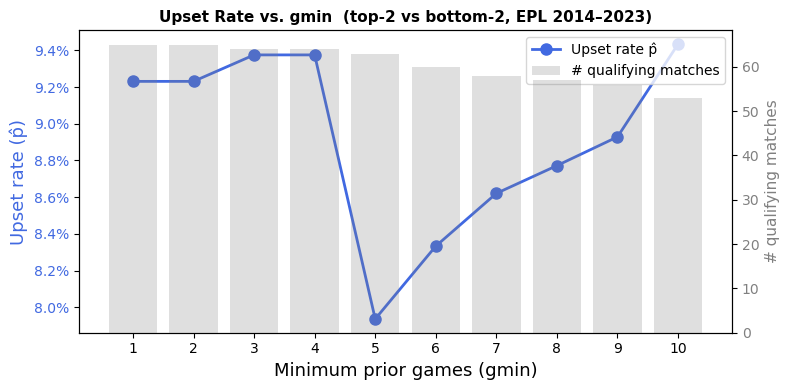


gmin | p̂       | n matches
   1 | 0.0923   | 65
   2 | 0.0923   | 65
   3 | 0.0938   | 64
   4 | 0.0938   | 64
   5 | 0.0794   | 63
   6 | 0.0833   | 60
   7 | 0.0862   | 58
   8 | 0.0877   | 57
   9 | 0.0893   | 56
  10 | 0.0943   | 53


In [23]:
gmin_values  = list(range(1, 11))
upset_rates  = []
match_counts = []

for gmin in gmin_values:
    q  = get_upsets(match_analysis, gmin)
    n_ = len(q)
    k_ = int(q['bottom_two_win'].sum()) if n_ > 0 else 0
    upset_rates.append(k_ / n_ if n_ > 0 else 0.0)
    match_counts.append(n_)

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(gmin_values, upset_rates, 'o-', color='royalblue',
         linewidth=2, markersize=8, label='Upset rate p̂')
ax1.set_xlabel('Minimum prior games (gmin)', fontsize=13)
ax1.set_ylabel('Upset rate (p̂)', fontsize=13, color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.set_xticks(gmin_values)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

ax2 = ax1.twinx()
ax2.bar(gmin_values, match_counts, alpha=0.25, color='grey', label='# qualifying matches')
ax2.set_ylabel('# qualifying matches', fontsize=11, color='grey')
ax2.tick_params(axis='y', labelcolor='grey')

ax1.set_title('Upset Rate vs. gmin  (top-2 vs bottom-2, EPL 2014–2023)',
              fontsize=11, fontweight='bold')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
plt.tight_layout()
plt.savefig('upset_rate_vs_gmin.png', dpi=150)
plt.show()

print('\ngmin | p̂       | n matches')
for g, p, n_ in zip(gmin_values, upset_rates, match_counts):
    print(f'  {g:2d} | {p:.4f}   | {n_}')

THe upset rate starts stable, and then has a weird massive drop off at gmin = 5. Most likely this is due to something within the data, where upsets are being cuttoff right before this gmin, as they start rising again afterwards. Interestingly, the gmin = 10 yielded the highest upset rate, which isn't super intuitive, as I would expect there to be more upsets at the very start of the season when a team could have just won one game and lost one game to be 1st and last respectively, but those places wouldn't be reflective of their true skill.

---
## Part (e) – Empirical Goal-Scoring Matrix G_mean[i, j]

Build 20×20 arrays:
- `G_tot[i-1, j-1]` – cumulative goals scored by a rank-i team against a rank-j team (pooled across all seasons)
- `G_n[i-1, j-1]` – number of such team-match observations

Each match contributes **two** directed entries: one for the home team scoring, one for the away team scoring.

In [25]:
G_tot = np.zeros((20, 20))
G_n   = np.zeros((20, 20))

for _, row in match_analysis.iterrows():
    hr = int(row['home_pre_rank']) - 1   # 0-indexed
    ar = int(row['away_pre_rank']) - 1
    hg = row['home_goals']
    ag = row['away_goals']

    if 0 <= hr < 20 and 0 <= ar < 20:
        # i. Home-team update: rank-(hr+1) scored hg against rank-(ar+1)
        G_tot[hr, ar] += hg
        G_n  [hr, ar] += 1
        # ii. Away-team update: rank-(ar+1) scored ag against rank-(hr+1)
        G_tot[ar, hr] += ag
        G_n  [ar, hr] += 1

with np.errstate(invalid='ignore'):
    G_mean = np.where(G_n > 0, G_tot / G_n, np.nan)

print('G_mean shape:', G_mean.shape)
print(f'Range (non-NaN): {np.nanmin(G_mean):.3f} – {np.nanmax(G_mean):.3f}')

G_mean shape: (20, 20)
Range (non-NaN): 0.364 – 3.158


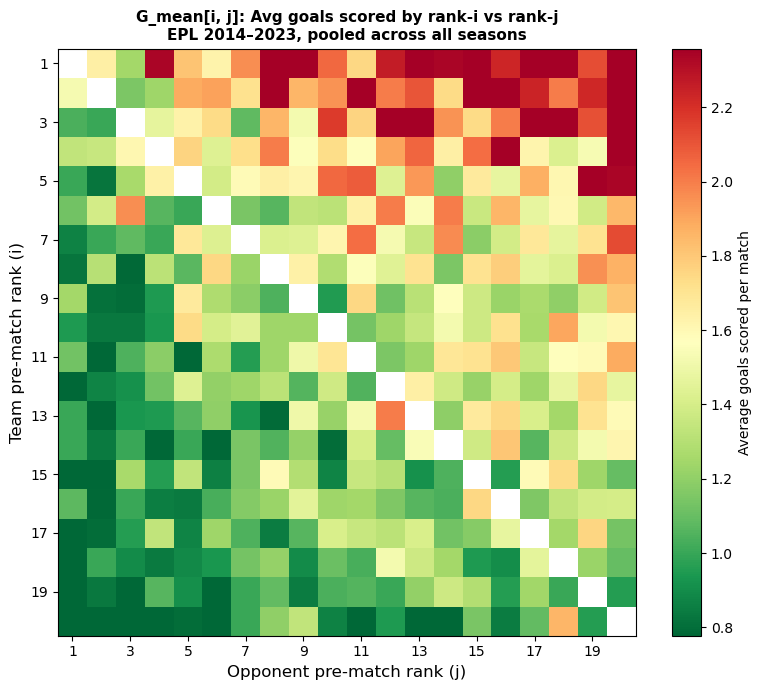

In [64]:
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(G_mean, cmap='RdYlGn_r', aspect='auto',
               vmin=np.nanpercentile(G_mean, 5),
               vmax=np.nanpercentile(G_mean, 95))
plt.colorbar(im, ax=ax, label='Average goals scored per match')

ticks = list(range(0, 20, 2))
ax.set_xticks(ticks); ax.set_xticklabels([str(t+1) for t in ticks])
ax.set_yticks(ticks); ax.set_yticklabels([str(t+1) for t in ticks])
ax.set_xlabel('Opponent pre-match rank (j)', fontsize=12)
ax.set_ylabel('Team pre-match rank (i)',     fontsize=12)
ax.set_title('G_mean[i, j]: Avg goals scored by rank-i vs rank-j\n'
             'EPL 2014–2023, pooled across all seasons',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('goal_scoring_heatmap.png', dpi=150)
plt.show()

THe teams with the higher pre match rank score more goals than the rest, with teams 1-3 being quite consistent, before it becomes more inconsistent. Interestingly, team 13 seems to outperform team 12 by a solid margin, which is interesting. There are some other weird outliers, but more or less this looks about right to me. 

---
## Part (f) – A Simple Generative Model for Match Outcomes from Ranks

### Model description (in words)

The heatmap gives `G_mean[i-1, j-1]`, which is the empirical average goals scored per game by a rank i team against a rank j team. Goals in football are rare, discrete, non negative events that occur semi independently throughout a match, making them well modelled by a Poisson distribution.

**`model_outcome(rank_i, rank_j)`:**
1. Look up `λ_i = G_mean[rank_i-1, rank_j-1]` and `λ_j = G_mean[rank_j-1, rank_i-1]`.
2. Sample `g_i ~ Poisson(λ_i)` and `g_j ~ Poisson(λ_j)` independently.
3. If `g_i > g_j` → team *i* wins; equal → draw; `g_i < g_j` → team *j* wins.


### Simulating a full EPL season
Generate all 380 fixtures (20 teams × 19 opponents × 2 directions). For each fixture call `model_outcome(rank_i, rank_j)` using the teams' initial (pre-season) ranks to look up `G_mean`. Accumulate points/GD/GF as in Part (b), then rank the teams at the end for final standings.

### Model evaluation Ideas (across 500 simulated seasons)
- Upset rate: compare the simulated fraction of rank-19/20 beating rank-1/2 with empirical `p̂`.
- Champion distribution: does rank-1 win the title most often?
- Points distribution:do champion point totals match historical EPL (~80–100 pts)? Same for teams that are getting relegated, were there any brutal cuttoffs? 
- Goals per game: does the distribution of simulated goals per game match the empirical one?

In [29]:
# ── EXTRA CREDIT: Simulate 500 EPL seasons ────────────────────────────────

GLOBAL_MEAN = float(np.nanmean(G_mean))  # fallback for any empty cell

def model_outcome(rank_i: int, rank_j: int) -> tuple:
    """Return (goals_i, goals_j) drawn from Poisson(G_mean[i,j])."""
    lam_i = G_mean[rank_i - 1, rank_j - 1]
    lam_j = G_mean[rank_j - 1, rank_i - 1]
    lam_i = GLOBAL_MEAN if np.isnan(lam_i) else lam_i
    lam_j = GLOBAL_MEAN if np.isnan(lam_j) else lam_j
    return np.random.poisson(lam_i), np.random.poisson(lam_j)


def simulate_season(n_teams: int = 20) -> pd.DataFrame:
    """Simulate a full 380-game EPL season and return final standings."""
    teams = [f'Team{i}' for i in range(1, n_teams + 1)]
    irank = {t: i + 1 for i, t in enumerate(teams)}  # initial rank
    rec   = {t: dict(W=0, D=0, L=0, GF=0, GA=0) for t in teams}

    for home in teams:
        for away in teams:
            if home == away:
                continue
            gi, gj = model_outcome(irank[home], irank[away])
            rec[home]['GF'] += gi; rec[home]['GA'] += gj
            rec[away]['GF'] += gj; rec[away]['GA'] += gi
            if gi > gj:
                rec[home]['W'] += 1; rec[away]['L'] += 1
            elif gi == gj:
                rec[home]['D'] += 1; rec[away]['D'] += 1
            else:
                rec[away]['W'] += 1; rec[home]['L'] += 1

    rows = []
    for t in teams:
        r = rec[t]
        pts = 3 * r['W'] + r['D']
        gd  = r['GF'] - r['GA']
        rows.append({'Team': t, 'initial_rank': irank[t],
                     'Pts': pts, 'GD': gd, 'GF': r['GF'],
                     'W': r['W'], 'D': r['D'], 'L': r['L']})

    standings = pd.DataFrame(rows).sort_values(
        ['Pts', 'GD', 'GF', 'Team'], ascending=[False, False, False, True]
    ).reset_index(drop=True)
    standings['final_rank'] = standings.index + 1
    return standings


N_SIMS = 500
np.random.seed(42)

champion_counts   = {}
champion_pts_list = []
rank1_final_ranks = []

for _ in range(N_SIMS):
    s     = simulate_season()
    champ = s.iloc[0]['Team']
    champion_counts[champ] = champion_counts.get(champ, 0) + 1
    champion_pts_list.append(s.iloc[0]['Pts'])
    rank1_final_ranks.append(
        int(s[s['initial_rank'] == 1]['final_rank'].values[0])
    )

print(f'Simulated {N_SIMS} seasons.')
print('\nChampion frequency (top 5):')
for team, cnt in sorted(champion_counts.items(), key=lambda x: -x[1])[:5]:
    print(f'  {team:10s}: {cnt:3d}  ({100*cnt/N_SIMS:.1f}%)')
print(f'\nMean champion points:  {np.mean(champion_pts_list):.1f}')
print(f'Team1 avg final rank:  {np.mean(rank1_final_ranks):.2f}')
print(f'Team1 wins title:      {100*champion_counts.get("Team1",0)/N_SIMS:.1f}% of simulations')

Simulated 500 seasons.

Champion frequency (top 5):
  Team1     : 246  (49.2%)
  Team2     : 175  (35.0%)
  Team3     :  47  (9.4%)
  Team4     :  27  (5.4%)
  Team5     :   2  (0.4%)

Mean champion points:  85.0
Team1 avg final rank:  1.81
Team1 wins title:      49.2% of simulations


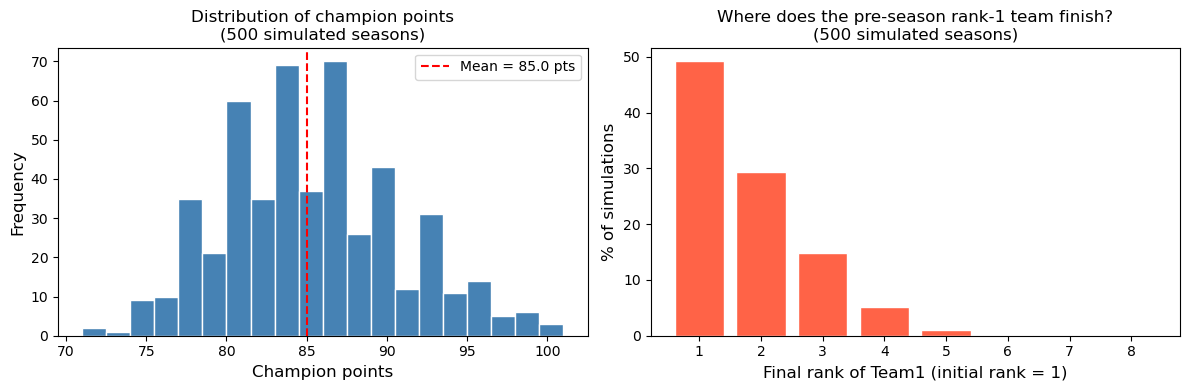

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Champion points distribution
axes[0].hist(champion_pts_list, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(np.mean(champion_pts_list), color='red', linestyle='--',
                label=f'Mean = {np.mean(champion_pts_list):.1f} pts')
axes[0].set_xlabel('Champion points', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of champion points\n(500 simulated seasons)')
axes[0].legend()

# Final rank distribution of initial rank-1 team
rc = pd.Series(rank1_final_ranks).value_counts().sort_index()
axes[1].bar(rc.index, rc.values / N_SIMS * 100, color='tomato', edgecolor='white')
axes[1].set_xlabel('Final rank of Team1 (initial rank = 1)', fontsize=12)
axes[1].set_ylabel('% of simulations', fontsize=12)
axes[1].set_title('Where does the pre-season rank-1 team finish?\n(500 simulated seasons)')

plt.tight_layout()
plt.savefig('simulation_evaluation.png', dpi=150)
plt.show()

In [31]:
# Compare simulated upset rate against empirical p̂
MATCHUPS = [(20,1),(20,2),(19,1),(19,2)]
REPS     = 2000
np.random.seed(0)

sim_upsets = 0
sim_total  = 0
for ri, rj in MATCHUPS:
    for _ in range(REPS):
        gi, gj = model_outcome(ri, rj)
        sim_total += 1
        if gi > gj:          # bottom-ranked team wins
            sim_upsets += 1

sim_rate = sim_upsets / sim_total
print(f'Empirical upset rate (gmin={GMIN}): {p_hat:.4f}  ({p_hat*100:.2f}%)')
print(f'Simulated upset rate:               {sim_rate:.4f}  ({sim_rate*100:.2f}%)')

Empirical upset rate (gmin=5): 0.0794  (7.94%)
Simulated upset rate:               0.0726  (7.26%)


---
## Summary

The model did well at matching the upset rate, within .7 of the real rate. I also think it did a decent job of looking at the champion point totals, although I think it may have gotten a little wild on the left tail given the lowest PL point total champion had 75, and the next lowest was 78. Team 1 probably shouldv'e been able to fall much further than they did, at the very least to rank 7. That would be my biggest criticism of the model. 